from previous visualization:
- no missing values

  
count of days :
- algeria: 364
- tunisia : 353
  
but end and start day are the same

creating target variable :
 - créer la target à partir de la colonne type et confidence et après ça tu supprime toutes les autres colonnes sauf latitude et longitude




# Importing env and libaries

In [9]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

In [10]:
from dotenv import load_dotenv
import os
from pathlib import Path

def load_environment():
    """Load environment variables and return them as a dictionary."""
    load_dotenv(Path("../utils/.env"))  # Loads .env from project root (works if run from notebook too)
    env_vars = {
        "IMAGE_FOLDER": os.getenv("IMAGE_FOLDER"),
        "EXTRACTEDDATASET_FOLDER": os.getenv("EXTRACTEDDATASET_FOLDER"),
        "DATASETS_FOLDER": os.getenv("DATASETS_FOLDER"),
        "ElevationDataset": os.getenv("ElevationDataset"),
        "LandCoverDataset": os.getenv("LandCoverDataset"),
        "GeoBoundaries": os.getenv("GeoBoundaries"),
        "EXTRACTEDELEVATION_FOLDER": os.getenv("EXTRACTEDELEVATION_FOLDER"),
        "EXTRACTEDLANDCOVER_FOLDER": os.getenv("EXTRACTEDLANDCOVER_FOLDER"),
        "EXTRACTEDGEOBOUNDARIES_FOLDER": os.getenv("EXTRACTEDGEOBOUNDARIES_FOLDER"),
        "CLEANEDDATASET_FOLDER": os.getenv("CLEANEDDATASET_FOLDER"),
        "CLEANEDELEVATION_FOLDER": os.getenv("CLEANEDELEVATION_FOLDER"),
        "CLEANEDLANDCOVER_FOLDER": os.getenv("CLEANEDLANDCOVER_FOLDER"),
        "PREPROCESSED_DATASET_FOLDER": os.getenv("PREPROCESSED_DATASET_FOLDER"),
        "PREPROCESSED_ELEVATION_FOLDER": os.getenv("PREPROCESSED_ELEVATION_FOLDER"),
        "PREPROCESSED_LANDCOVER_FOLDER": os.getenv("PREPROCESSED_LANDCOVER_FOLDER")
    }
    return env_vars

folders = load_environment()
image_folder = folders["IMAGE_FOLDER"]
extractedData_folder = folders["EXTRACTEDDATASET_FOLDER"]
datasets_folder = folders["DATASETS_FOLDER"]
landCover_folder = folders["LandCoverDataset"]
elevation_folder = folders["ElevationDataset"]
geoboundaries_folder = folders["GeoBoundaries"]
extracted_elevation_folder = folders["EXTRACTEDELEVATION_FOLDER"]
extracted_landcover_folder = folders["EXTRACTEDLANDCOVER_FOLDER"]
extracted_geo_boundaries_folder = folders["EXTRACTEDGEOBOUNDARIES_FOLDER"]
cleaned_dataset_folder = folders["CLEANEDDATASET_FOLDER"]
cleaned_elevation_folder = folders["CLEANEDELEVATION_FOLDER"]
cleaned_landcover_folder = folders["CLEANEDLANDCOVER_FOLDER"]
preprocessed_dataset_folder = folders["PREPROCESSED_DATASET_FOLDER"]
preprocessed_elevation_folder = folders["PREPROCESSED_ELEVATION_FOLDER"]
preprocessed_landcover_folder = folders["PREPROCESSED_LANDCOVER_FOLDER"]


# Reading the file

In [11]:
#  get fire geojson from f"{datasets_folder}/FireDataset/fires_dz_tn.geojson"
fire_df_init = pd.read_csv(f"{datasets_folder}/FireDataset/fire_df.csv")

# viewing   the first few rows of the geodataframe
fire_df_init.head()

# print(len(fire_df))  # --> 90250


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,27.72818,9.87200,295.51,0.76,0.77,2024-01-01,3,N20,VIIRS,n,2,277.66,1.24,N,2
1,28.63288,9.77909,301.80,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.05,1.57,N,2
2,28.64012,9.77953,298.65,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.04,1.34,N,2
3,36.74886,6.25409,338.04,0.46,0.39,2024-01-01,141,N20,VIIRS,n,2,257.28,5.21,N,2
4,35.87978,4.44782,309.49,0.41,0.37,2024-01-01,141,N20,VIIRS,n,2,272.08,1.58,N,2


# preprocessing

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
C:\Users\moous\AppData\Local\Temp\ipykernel_6856\1650591268.py:19: SyntaxWarning: invalid escape sequence '\l'
  print("\longitude quantiles:")


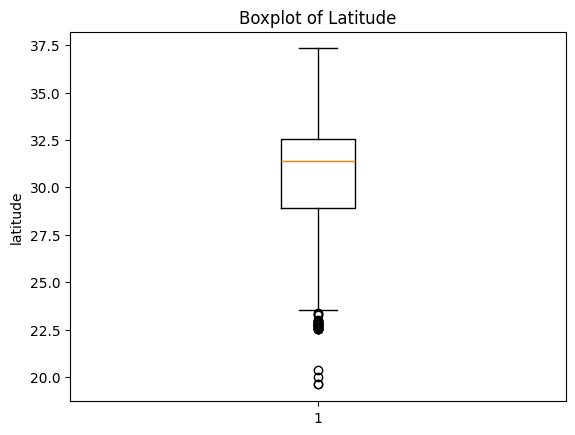


Latitude quantiles:
0.00    19.603230
0.25    28.911510
0.50    31.409125
0.75    32.560313
1.00    37.323460
Name: latitude, dtype: float64


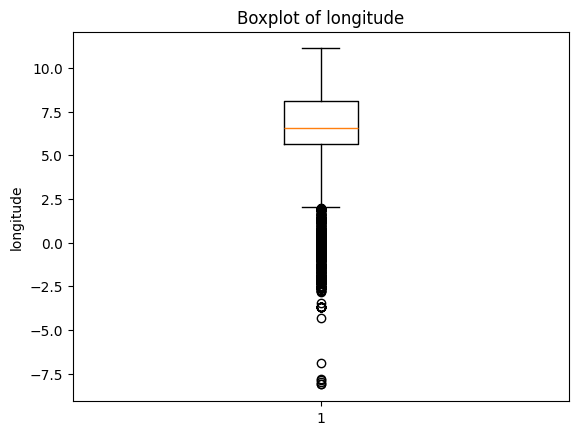

\longitude quantiles:
0.00    -8.118050
0.25     5.642160
0.50     6.557880
0.75     8.083758
1.00    11.110350
Name: longitude, dtype: float64


In [12]:
#  view longtitude boxplot to know where to cut --> to add non fire rows
import matplotlib.pyplot as plt

plt.boxplot(fire_df_init['latitude'])
plt.title("Boxplot of Latitude")
plt.ylabel("latitude")
plt.show()

#  print quantiles
print("\nLatitude quantiles:")
print(fire_df_init['latitude'].quantile([0, 0.25, 0.5, 0.75, 1]))

plt.boxplot(fire_df_init['longitude'])
plt.title("Boxplot of longitude")
plt.ylabel("longitude")
plt.show()

#  print quantiles
print("\longitude quantiles:")
print(fire_df_init['longitude'].quantile([0, 0.25, 0.5, 0.75, 1]))


latitude north is mostly whithin 30 and 37.5 ( view in fire visualiation map latitude lontitude vs FRP) --> fill those with negative fire

In [13]:
# keep latitude longtitude confidence type columns only
fire_df = fire_df_init[['latitude','longitude','type']]

# create dataframe where type= 1 for forest fires
fire_type0_df = fire_df[fire_df['type'] == 0]
fire_type0_df.head()
print(len(fire_type0_df))

14216


In [14]:
# add a column fire 
fire_df['fire'] = (fire_df['type'] == 0).astype(int)

# print where fire=1
fire_df_final = fire_df[fire_df['fire'] ==1]


C:\Users\moous\AppData\Local\Temp\ipykernel_6856\4132470911.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fire_df['fire'] = (fire_df['type'] == 0).astype(int)


## chosing optimal range of altitude longitutde


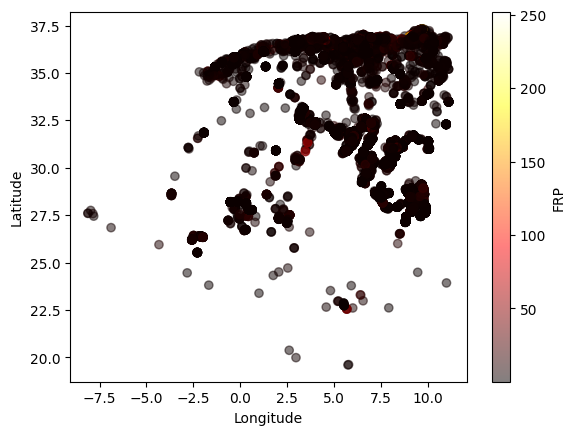

only type 1


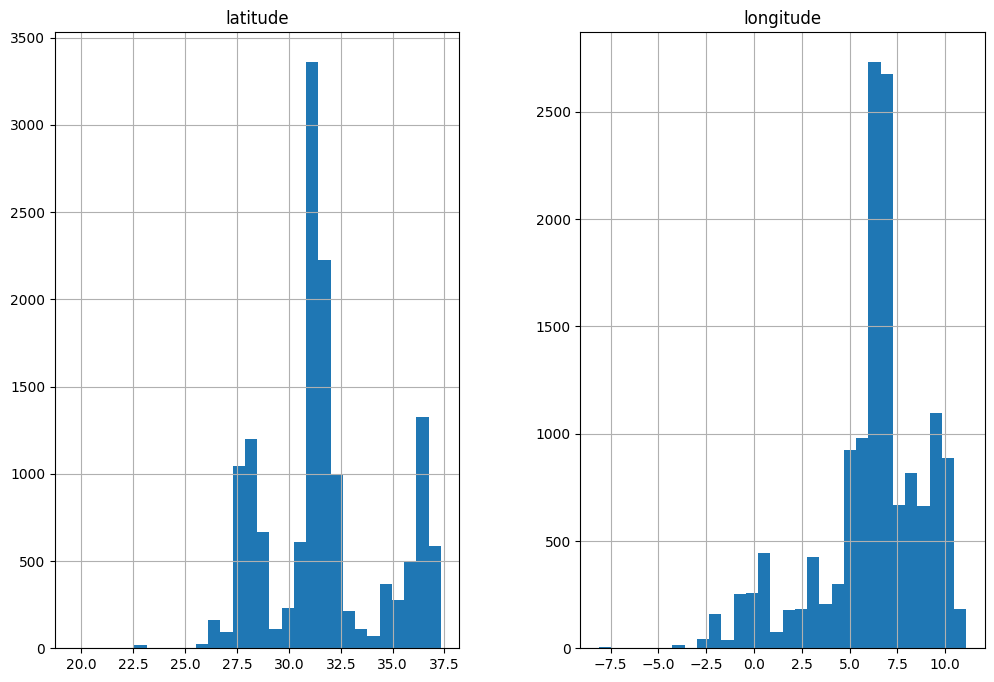

all types


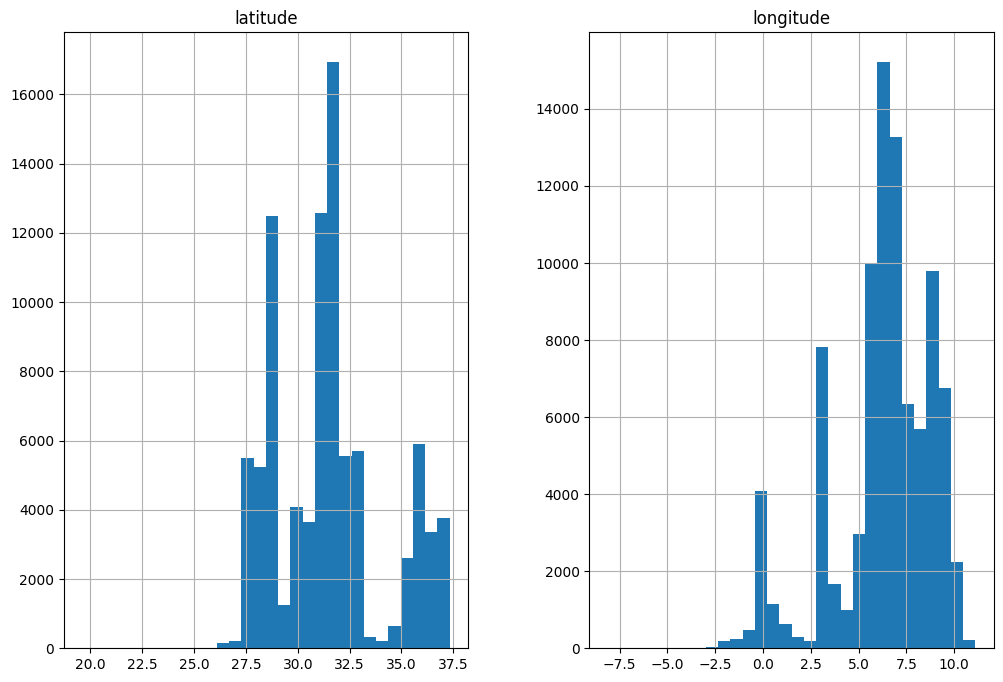

In [15]:
# distribution of altitude longtitude in fire_df_final dataframe
import matplotlib.pyplot as plt
columns = ['latitude','longitude']
print('only type 1')
fire_df_final[columns].hist(bins=30, figsize=(12,8))
plt.show()

print("all types")
fire_df_init[columns].hist(bins=30, figsize=(12,8))
plt.show()


In [ ]:
# checking max longitude and latitude exactly
print(max(fire_df_final['latitude']))
print(max(fire_df_final['longitude']))

37.32346
11.11035


chosen range from viz:
- latitude: [26, 37.32346] 
- Longitude: [-2.5, 11.11035]  

## converting to geodataframe for later merge

In [16]:
import geopandas as gpd

# Convert fire_df to GeoDataFrame
fire_df_final = gpd.GeoDataFrame(
    fire_df_final,
    geometry=gpd.points_from_xy(fire_df_final.longitude, fire_df_final.latitude),
    crs="EPSG:4326"
)

In [ ]:
fire_df_final.head()

,latitude,longitude,type,fire,geometry
5,35.70751,5.53337,0,1,POINT (5.53337 35.70751)
13,32.13579,6.46961,0,1,POINT (6.46961 32.13579)
20,32.35563,6.97630,0,1,POINT (6.9763 32.35563)
64,28.19791,9.39581,0,1,POINT (9.39581 28.19791)
67,28.12826,9.49323,0,1,POINT (9.49323 28.12826)


In [17]:
fire_df_final = fire_df_final[['fire','geometry']]

In [18]:
# save geodataframe fire type 1 in preprocessed folder inside FireDataset
# Create output directory
output_dir = f"{preprocessed_dataset_folder}\FireDataset"
os.makedirs(output_dir, exist_ok=True)

# Define output file path (choose your preferred format)
output_path = os.path.join(output_dir, "fire_type_1.geojson")

# Save GeoDataFrame
fire_df_final.to_file(output_path, driver="GeoJSON")

print(f"Saved: {output_path}")

<>:3: SyntaxWarning: invalid escape sequence '\F'
<>:3: SyntaxWarning: invalid escape sequence '\F'
C:\Users\moous\AppData\Local\Temp\ipykernel_6856\712471572.py:3: SyntaxWarning: invalid escape sequence '\F'
  output_dir = f"{preprocessed_dataset_folder}\FireDataset"


Saved: ../../PreprocessedDatasets\FireDataset\fire_type_1.geojson
